# Nome:Bruna Tatiane Farias Ferreira
 *aluno especial*

## Import all packages need in the cell below

In [1]:
using Plots, Optim, NLsolve, LinearAlgebra, ForwardDiff, JuMP, HiGHS

## FONC example

Plot the graphics of $f(x) = (x_1 - 3)^2 + (x_2 + 4)^2$

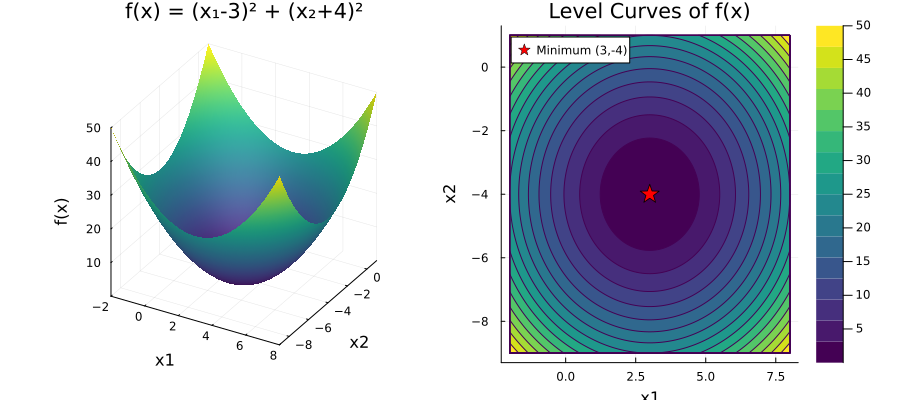

In [2]:
f1(x1, x2) = (x1 - 3)^2 + (x2 + 4)^2

x1_range = range(-2, 8, length=200)
x2_range = range(-9, 1, length=200)
Z = [f1(x1, x2) for x2 in x2_range, x1 in x1_range]

p1 = surface(x1_range, x2_range, Z, xlabel="x1", ylabel="x2", zlabel="f(x)",
             title="f(x) = (x₁-3)² + (x₂+4)²", color=:viridis, legend=false)
p2 = contourf(x1_range, x2_range, Z, xlabel="x1", ylabel="x2",
              title="Level Curves of f(x)", color=:viridis)
scatter!(p2, [3], [-4], color=:red, marker=:star5, markersize=10, label="Minimum (3,-4)")
plot(p1, p2, layout=(1,2), size=(900,400))

## Solving the FONC

Given the function $z = (x_1 - 1)^4 + (x_2 - 2)^4$:

* using the optim.jl package, find the minimum of z.
* using the NLsolve.jl package, solve the FONC problem for this function

In [3]:
z(x) = (x[1] - 1)^4 + (x[2] - 2)^4

# Minimum via Optim.jl
result_optim = optimize(z, [0.0, 0.0], BFGS())
println("=== Optim.jl - Minimum of z ===")
println("Minimizer: ", Optim.minimizer(result_optim))
println("Minimum value: ", Optim.minimum(result_optim))

# FONC: ∇z = 0 via NLsolve
# ∂z/∂x1 = 4(x1-1)^3, ∂z/∂x2 = 4(x2-2)^3
function fonc!(F, x)
    F[1] = 4*(x[1] - 1)^3
    F[2] = 4*(x[2] - 2)^3
end

result_nlsolve = nlsolve(fonc!, [0.0, 0.0])
println("\n=== NLsolve.jl - FONC solution ===")
println("Solution: ", result_nlsolve.zero)
println("Converged: ", converged(result_nlsolve))

=== Optim.jl - Minimum of z ===
Minimizer: [0.9993307703501523, 2.0007158804901986]
Minimum value: 4.632267842351608e-13

=== NLsolve.jl - FONC solution ===
Solution: [0.9995401607802424, 1.9990803216092672]
Converged: true


Plot the level curve and the graphics of $f(x) = (x_1 - 3)^2 + (x_2 - 2)^2$

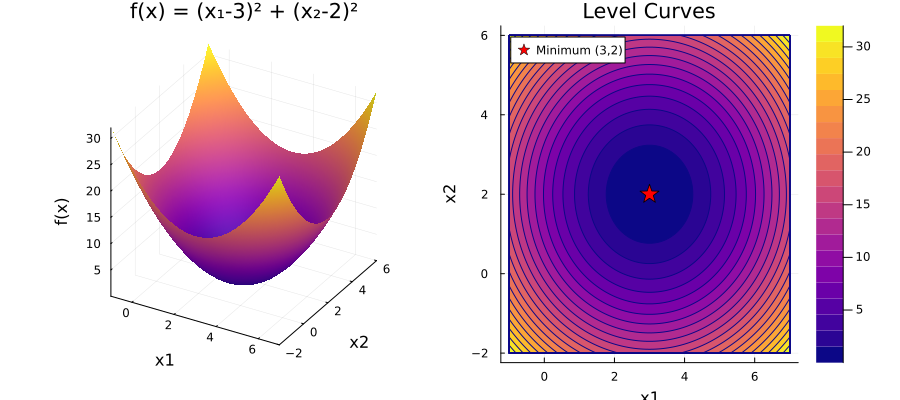

In [4]:
f2(x1, x2) = (x1 - 3)^2 + (x2 - 2)^2

x1_r = range(-1, 7, length=200)
x2_r = range(-2, 6, length=200)
Z2 = [f2(x1, x2) for x2 in x2_r, x1 in x1_r]

p1 = surface(x1_r, x2_r, Z2, xlabel="x1", ylabel="x2", zlabel="f(x)",
             title="f(x) = (x₁-3)² + (x₂-2)²", color=:plasma, legend=false)
p2 = contourf(x1_r, x2_r, Z2, xlabel="x1", ylabel="x2",
              title="Level Curves", color=:plasma, levels=20)
scatter!(p2, [3], [2], color=:red, marker=:star5, markersize=10, label="Minimum (3,2)")
plot(p1, p2, layout=(1,2), size=(900,400))

Starting from the point $x = [1.0, 1.0]$, implement the gradient descent and Newton method to find the minimum of this function.

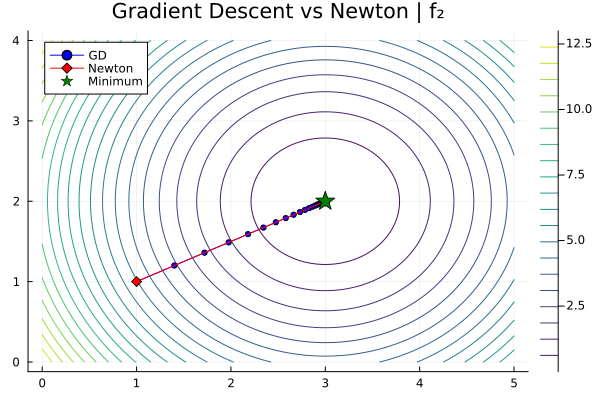

=== f(x) = (x₁-3)² + (x₂-2)² | x₀ = [1,1] ===
Gradient Descent: [2.9999999962057253, 1.9999999981028627] | iters: 90
Newton Method:    [3.0, 2.0] | iters: 1


In [5]:
# f(x) = (x1-3)^2 + (x2-2)^2
f2(x) = (x[1] - 3)^2 + (x[2] - 2)^2
∇f2(x) = [2*(x[1] - 3), 2*(x[2] - 2)]
H2(x)  = [2.0 0.0; 0.0 2.0]  # constant Hessian

function grad_descent(f, ∇f, x0; lr=0.1, tol=1e-8, maxiter=10000)
    x = copy(x0); path = [copy(x)]
    for i in 1:maxiter
        g = ∇f(x)
        norm(g) < tol && break
        x = x - lr * g
        push!(path, copy(x))
    end
    x, path
end

function newton_method(f, ∇f, H, x0; tol=1e-8, maxiter=1000)
    x = copy(x0); path = [copy(x)]
    for i in 1:maxiter
        g = ∇f(x)
        norm(g) < tol && break
        x = x - H(x) \ g
        push!(path, copy(x))
    end
    x, path
end

x0 = [1.0, 1.0]
xgd, path_gd = grad_descent(f2, ∇f2, x0)
xnt, path_nt = newton_method(f2, ∇f2, H2, x0)

println("=== f(x) = (x₁-3)² + (x₂-2)² | x₀ = [1,1] ===")
println("Gradient Descent: ", xgd, " | iters: ", length(path_gd)-1)
println("Newton Method:    ", xnt, " | iters: ", length(path_nt)-1)

# Plot convergence paths
x1_r = range(0, 5, length=150); x2_r = range(0, 4, length=150)
Z = [f2([x1,x2]) for x2 in x2_r, x1 in x1_r]
plt = contour(x1_r, x2_r, Z, levels=20, color=:viridis, title="Gradient Descent vs Newton | f₂")
plot!(plt, [p[1] for p in path_gd], [p[2] for p in path_gd], marker=:circle, ms=3, label="GD", color=:blue)
plot!(plt, [p[1] for p in path_nt], [p[2] for p in path_nt], marker=:diamond, ms=5, label="Newton", color=:red)
scatter!(plt, [3], [2], color=:green, marker=:star5, ms=10, label="Minimum")
display(plt)

Implement the same methods now for the function f(x) = 10(x_1 - 3)^2 + 2(x_2 - 2)^2$

=== f(x) = 10(x₁-3)² + 2(x₂-2)² | x₀ = [1,1] ===
Gradient Descent: [3.0, 1.9999999976674088] | iters: 114
Newton Method:    [3.0, 2.0] | iters: 1


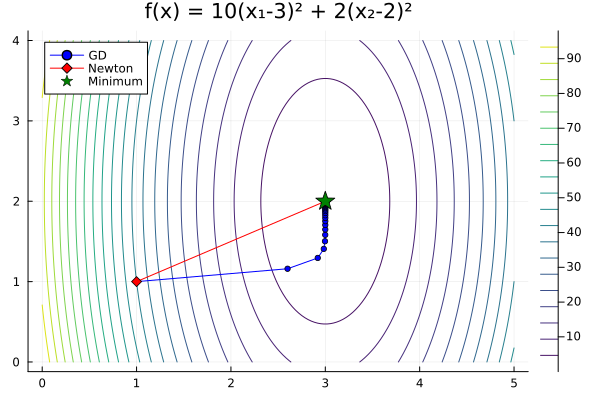

In [6]:
f3(x) = 10*(x[1]-3)^2 + 2*(x[2]-2)^2
∇f3(x) = [20*(x[1]-3), 4*(x[2]-2)]
H3(x)  = [20.0 0.0; 0.0 4.0]

x0 = [1.0, 1.0]
xgd3, path_gd3 = grad_descent(f3, ∇f3, x0, lr=0.04)
xnt3, path_nt3 = newton_method(f3, ∇f3, H3, x0)

println("=== f(x) = 10(x₁-3)² + 2(x₂-2)² | x₀ = [1,1] ===")
println("Gradient Descent: ", xgd3, " | iters: ", length(path_gd3)-1)
println("Newton Method:    ", xnt3, " | iters: ", length(path_nt3)-1)

x1_r = range(0,5,length=150); x2_r = range(0,4,length=150)
Z = [f3([x1,x2]) for x2 in x2_r, x1 in x1_r]
plt = contour(x1_r, x2_r, Z, levels=20, color=:viridis, title="f(x) = 10(x₁-3)² + 2(x₂-2)²")
plot!(plt, [p[1] for p in path_gd3], [p[2] for p in path_gd3], marker=:circle, ms=3, label="GD", color=:blue)
plot!(plt, [p[1] for p in path_nt3], [p[2] for p in path_nt3], marker=:diamond, ms=5, label="Newton", color=:red)
scatter!(plt, [3],[2], color=:green, marker=:star5, ms=10, label="Minimum")
display(plt)

Now implement the same methods for the function $f(x) = x_1^2 + x_2^2$. Use as start point $x_0 = [-2.0, 2.0]$

=== f(x) = x₁² + x₂² | x₀ = [-2,2] ===
Gradient Descent: [-3.035420144102704e-9, 3.035420144102704e-9] | iters: 91
Newton Method:    [0.0, 0.0] | iters: 1


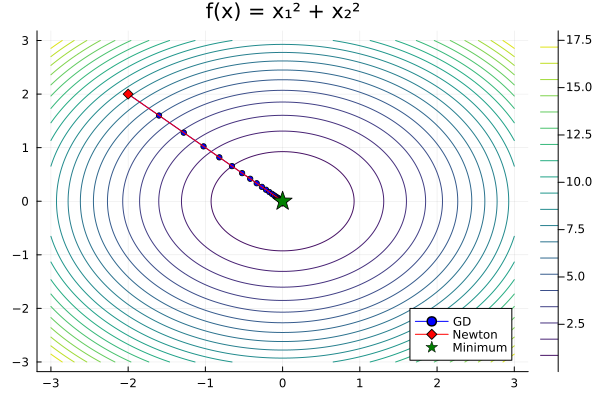

In [7]:
f4(x) = x[1]^2 + x[2]^2
∇f4(x) = [2*x[1], 2*x[2]]
H4(x)  = [2.0 0.0; 0.0 2.0]

x0 = [-2.0, 2.0]
xgd4, path_gd4 = grad_descent(f4, ∇f4, x0)
xnt4, path_nt4 = newton_method(f4, ∇f4, H4, x0)

println("=== f(x) = x₁² + x₂² | x₀ = [-2,2] ===")
println("Gradient Descent: ", xgd4, " | iters: ", length(path_gd4)-1)
println("Newton Method:    ", xnt4, " | iters: ", length(path_nt4)-1)

x1_r = range(-3,3,length=150); x2_r = range(-3,3,length=150)
Z = [f4([x1,x2]) for x2 in x2_r, x1 in x1_r]
plt = contour(x1_r, x2_r, Z, levels=20, color=:viridis, title="f(x) = x₁² + x₂²")
plot!(plt, [p[1] for p in path_gd4], [p[2] for p in path_gd4], marker=:circle, ms=3, label="GD", color=:blue)
plot!(plt, [p[1] for p in path_nt4], [p[2] for p in path_nt4], marker=:diamond, ms=5, label="Newton", color=:red)
scatter!(plt, [0],[0], color=:green, marker=:star5, ms=10, label="Minimum")
display(plt)

Implement the same methods for the function $f(x) = x_1^2 + 100x_2^2$. Use as start point $x_0 = [-2.0, 2.0]$

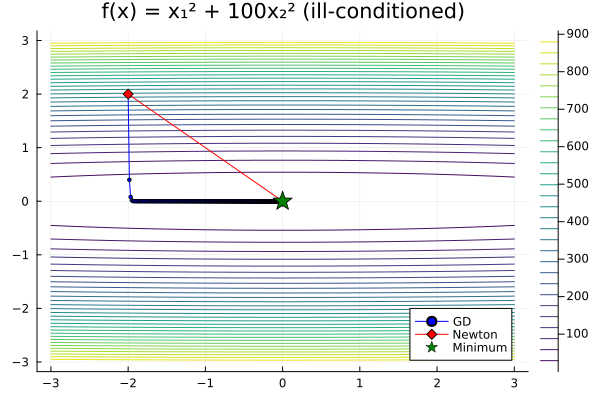

=== f(x) = x₁² + 100x₂² | x₀ = [-2,2] ===
Gradient Descent: [-4.9981988225948785e-9, 0.0] | iters: 2466
Newton Method:    [0.0, 0.0] | iters: 1

Observation: GD struggles with ill-conditioned problems (high condition number κ=100)
Newton converges in 1 step since f is quadratic


In [8]:
f5(x) = x[1]^2 + 100*x[2]^2
∇f5(x) = [2*x[1], 200*x[2]]
H5(x)  = [2.0 0.0; 0.0 200.0]

x0 = [-2.0, 2.0]
xgd5, path_gd5 = grad_descent(f5, ∇f5, x0, lr=0.004)
xnt5, path_nt5 = newton_method(f5, ∇f5, H5, x0)

println("=== f(x) = x₁² + 100x₂² | x₀ = [-2,2] ===")
println("Gradient Descent: ", xgd5, " | iters: ", length(path_gd5)-1)
println("Newton Method:    ", xnt5, " | iters: ", length(path_nt5)-1)

x1_r = range(-3,3,length=150); x2_r = range(-3,3,length=150)
Z = [f5([x1,x2]) for x2 in x2_r, x1 in x1_r]
plt = contour(x1_r, x2_r, Z, levels=30, color=:viridis, title="f(x) = x₁² + 100x₂² (ill-conditioned)")
plot!(plt, [p[1] for p in path_gd5], [p[2] for p in path_gd5], marker=:circle, ms=2, label="GD", color=:blue)
plot!(plt, [p[1] for p in path_nt5], [p[2] for p in path_nt5], marker=:diamond, ms=5, label="Newton", color=:red)
scatter!(plt, [0],[0], color=:green, marker=:star5, ms=10, label="Minimum")
display(plt)

println("\nObservation: GD struggles with ill-conditioned problems (high condition number κ=100)")
println("Newton converges in 1 step since f is quadratic")

For the last problem, perform the change of variables: $x_2 = \frac{1}{10}y_2$

##  Gradient Descent with Backtracking Line Search:

Given function:
\begin{align*}
    f(x_1, x_2, x_3) = x_{3} \log \Big( e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}} \Big) + (x_{3}-2)^2 + e^{\frac{1}{x_{1} + x_{2}}}
\end{align*}

$ \textbf{dom} \; f: \{ \mathbf{x} \in \mathbb{R}^3 : x_1 +x _2 >0, x_3 > 0 \}  $

Define the function in the cell below:

In [9]:
# Change of variables note for f(x) = x₁² + 100x₂²:
# Let x₂ = (1/10)y₂  →  f becomes x₁² + 100*(y₂/10)² = x₁² + y₂²
# The problem becomes well-conditioned (κ=1)
f5_cov(y) = y[1]^2 + y[2]^2          # after change of variables
x0_cov    = [-2.0, 20.0]              # x₂=2 → y₂ = 10*x₂ = 20
xgd_cov, path_gd_cov = grad_descent(f5_cov,
                                     y -> ForwardDiff.gradient(f5_cov, y),
                                     x0_cov, lr=0.1)
println("After change of variables y₂ = 10·x₂:")
println("GD converges in ", length(path_gd_cov)-1,
        " iterations (vs ", length(path_gd5)-1, " before)")

# ===== Define the 3-variable function for Backtracking section =====
f_bt(x) = x[3]*log(exp(x[1]/x[3]) + exp(x[2]/x[3])) +
           (x[3]-2)^2 + exp(1/(x[1]+x[2]))

# Domain: x1+x2 > 0, x3 > 0
in_domain(x) = (x[1] + x[2] > 0) && (x[3] > 0)

println("\nf_bt([3.0, 4.0, 5.0]) = ", f_bt([3.0, 4.0, 5.0]))
println("In domain: ", in_domain([3.0, 4.0, 5.0]))


After change of variables y₂ = 10·x₂:
GD converges in 100 iterations (vs 2466 before)

f_bt([3.0, 4.0, 5.0]) = 17.144259341803068
In domain: true


Defining the first derivative: 

$\nabla f = [ \partial f/\partial x_1 \; \partial f/\partial x_2 \; \partial f/\partial x_3]^T   $

$$ \implies \nabla f = \begin{Bmatrix}
\frac{e^{\frac{x_{1}} {x_{3}}}}{e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}} - \frac{e^{ \frac{1}{x_1 + x_2}}}{(x_1 +x_2)^2}  \\ \\
\frac{e^{\frac{x_{2}} {x_{3}}}}{e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}} - \frac{e^{ \frac{1}{x_1 + x_2}}}{(x_1 +x_2)^2} \\ \\
 log(e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}) - \frac{x_1 e^{\frac{x_{1}} {x_{3}}} + x_2 e^{\frac{x_{2}} {x_{3}}}}{x_3 ( e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}) } + 2(x_3-2)
\end{Bmatrix}$$

#### implement the first derivative 

In [10]:
function ∇f_bt(x)
    x1, x2, x3 = x[1], x[2], x[3]
    e1      = exp(x1/x3)
    e2      = exp(x2/x3)
    esum    = e1 + e2
    exp_t   = exp(1/(x1+x2))
    denom   = (x1+x2)^2

    df1 = e1/esum - exp_t/denom
    df2 = e2/esum - exp_t/denom
    df3 = log(esum) - (x1*e1 + x2*e2)/(x3*esum) + 2*(x3-2)
    return [df1, df2, df3]
end

# Verify against ForwardDiff
x_test = [3.0, 4.0, 5.0]
println("Analytical ∇f : ", ∇f_bt(x_test))
println("ForwardDiff ∇f: ", ForwardDiff.gradient(f_bt, x_test))
println("Match: ", isapprox(∇f_bt(x_test),
                            ForwardDiff.gradient(f_bt, x_test), atol=1e-10))


Analytical ∇f : [0.42662385993456065, 0.5262918545595165, 6.688172069919096]
ForwardDiff ∇f: [0.42662385993456065, 0.5262918545595165, 6.688172069919096]
Match: true


Defining parameters for backtracking search: $\alpha = 0,4; \beta = 0,5;$ tolerance (eps) $= 10^{-5}$

In [11]:
α_bt = 0.4
β_bt = 0.5
eps_bt = 1e-5
println("Parameters: α=$α_bt, β=$β_bt, ε=$eps_bt")

Parameters: α=0.4, β=0.5, ε=1.0e-5


Start Point: [3.0, 4.0, 5.0]

In [12]:
x_start = [3.0, 4.0, 5.0]
println("Start point: ", x_start)
println("f(x_start) = ", f_bt(x_start))
println("∇f(x_start) = ", ∇f_bt(x_start))


Start point: [3.0, 4.0, 5.0]
f(x_start) = 17.144259341803068
∇f(x_start) = [0.42662385993456065, 0.5262918545595165, 6.688172069919096]


Ensuring domain:

$ \text{While} \; x + t\Delta x \notin \textbf{dom} f, \text{ set } t := \beta t $ \
where, $\Delta x = -\nabla f(x)$

In [13]:
function ensure_domain_gd(x, Δx, β)
    t = 1.0
    while !in_domain(x + t*Δx)
        t *= β
    end
    return t
end

# Test
x0_bt  = [3.0, 4.0, 5.0]
Δx_test = -∇f_bt(x0_bt)
t0 = ensure_domain_gd(x0_bt, Δx_test, β_bt)
println("Initial step size after domain check: ", t0)


Initial step size after domain check: 0.5


Backtracking algorithm:

$
\text{Given a descent direction } \Delta x = -\nabla f(x) \text{ for } f \text{ at } x \in \textbf{dom} f, \alpha \in (0, 0.5), \beta \in (0, 1).$

\begin{array}{l}
\text{Set } t := 1. \\ 
\text{Ensure domain:} \; \text{While} \; x + t\Delta x \notin \textbf{dom} f, \text{ set } t := \beta t \\
\text{While } f(x + t\Delta x) > f(x) + \alpha t \nabla f(x)^T \Delta x, \text{ set } t := \beta t.
\end{array}


In [14]:
function backtracking_gd(x, Δx, f, ∇f, α, β)
    t = 1.0
    # Ensure domain
    while !in_domain(x + t*Δx)
        t *= β
    end
    # Armijo condition
    while f(x + t*Δx) > f(x) + α*t*(∇f(x)' * Δx)
        t *= β
        if t < 1e-15; break; end
    end
    return t
end
println("Backtracking line search defined.")

Backtracking line search defined.


### Algorithm: Gradient Descent

1. **Input:** Starting point $x$ in $\text{dom} \, f$

2. **Repeat until stopping criterion is satisfied:**

    a. $\Delta x := -\nabla f(x)$
    
    b. **Line search:** Choose step size $t$ via backtracking line search
    
    c. **Update:** $x := x + t \Delta x$

=== Gradient Descent with Backtracking ===
Minimizer: [0.9261872701983407, 0.9262296480441212, 1.6534264097600675]
f(x*) = 3.908113786397637
‖∇f(x*)‖ = 9.061686067521745e-6
Iterations: 30


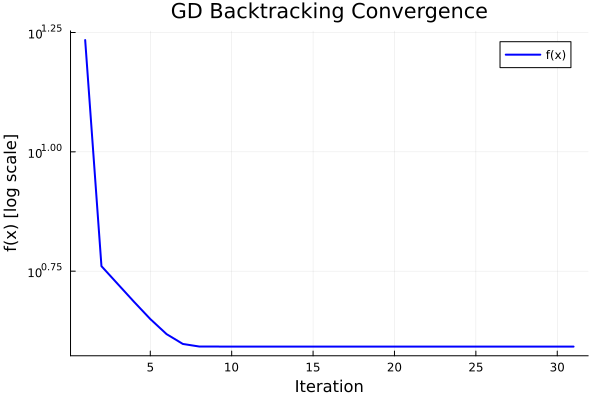

In [15]:
function gradient_descent_bt(f, ∇f, x0, α, β, eps; maxiter=10000)
    x = copy(x0)
    iter = 0
    f_history = [f(x)]
    for i in 1:maxiter
        g = ∇f(x)
        norm(g) < eps && break
        Δx = -g
        t = backtracking_gd(x, Δx, f, ∇f, α, β)
        x = x + t*Δx
        push!(f_history, f(x))
        iter = i
    end
    return x, iter, f_history
end

x_gd_bt, iters_gd, f_hist_gd = gradient_descent_bt(f_bt, ∇f_bt, x_start, α_bt, β_bt, eps_bt)

println("=== Gradient Descent with Backtracking ===")
println("Minimizer: ", x_gd_bt)
println("f(x*) = ", f_bt(x_gd_bt))
println("‖∇f(x*)‖ = ", norm(∇f_bt(x_gd_bt)))
println("Iterations: ", iters_gd)

plot(f_hist_gd, yscale=:log10, xlabel="Iteration", ylabel="f(x) [log scale]",
     title="GD Backtracking Convergence", label="f(x)", color=:blue, linewidth=2)

## Optimisation using Newton's Method:

Given function:
\begin{align*}
    f(x_1, x_2, x_3) = x_{3} \log \Big( e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}} \Big) + (x_{3}-2)^2 + e^{\frac{1}{x_{1} + x_{2}}}
\end{align*}

$ \textbf{dom} \; f: \{ \mathbf{x} \in \mathbb{R}^3 : x_1 +x _2 >0, x_3 > 0 \}  $

Defining the first derivative: 

$\nabla f = [ \partial f/\partial x_1 \; \partial f/\partial x_2 \; \partial f/\partial x_3]^T   $

$$ \implies \nabla f = \begin{Bmatrix}
\frac{e^{\frac{x_{1}} {x_{3}}}}{e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}} - \frac{e^{ \frac{1}{x_1 + x_2}}}{(x_1 +x_2)^2}  \\ \\
\frac{e^{\frac{x_{2}} {x_{3}}}}{e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}} - \frac{e^{ \frac{1}{x_1 + x_2}}}{(x_1 +x_2)^2} \\ \\
 log(e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}) - \frac{x_1 e^{\frac{x_{1}} {x_{3}}} + x_2 e^{\frac{x_{2}} {x_{3}}}}{x_3 ( e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}) } + 2(x_3-2)
\end{Bmatrix}$$

Defining the Second Derivative:

The gradient vector, denoted as $\nabla f$, is the vector of partial derivatives:
$
\nabla f(x) = \left(\frac{\partial f}{\partial x_1}, \frac{\partial f}{\partial x_2}, \ldots, \frac{\partial f}{\partial x_n}\right)
$

The finite difference approximation for the gradient at a point $x$ is given by:
$
\nabla_f(x) \approx \frac{f(x + h\mathbf{i}) - f(x)}{h}
$
where $\mathbf{i}$ is a unit vector along one of the coordinate axes.

The second derivative matrix is then approximated as:
$
\nabla^2 f(x) \approx \frac{1}{h} \left(\nabla_f(x + h\mathbf{i}) - \nabla_f(x)\right)
$

The reshaped second derivative matrix is a $3 \times 3$ matrix obtained from the flattened vector.

In [16]:
function hessian_fd(∇f, x; h=1e-5)
    n = length(x)
    H = zeros(n, n)
    g0 = ∇f(x)
    for i in 1:n
        ei = zeros(n); ei[i] = h
        gi = ∇f(x + ei)
        H[:, i] = (gi - g0) / h
    end
    return (H + H') / 2  # symmetrize
end

# Verify
H_test = hessian_fd(∇f_bt, x_start)
println("Hessian at x_start:")
display(H_test)
println("Is positive definite: ", all(eigvals(H_test) .> 0))

3×3 Matrix{Float64}:
  0.0567101   -0.0422966    0.00990063
 -0.0422966    0.0567101   -0.00990068
  0.00990063  -0.00990068   2.00198

Hessian at x_start:
Is positive definite: true


Defining parameters for backtracking search and the start point: $\alpha = 0,4; \beta = 0,5;$ tolerance (eps) $= 10^{-5}$; Start Point: [3.0, 4.0, 5.0]

In [17]:
# Same parameters + start point
α_nt = 0.4; β_nt = 0.5; eps_nt = 1e-5
x_start_nt = [3.0, 4.0, 5.0]
println("Newton params: α=$α_nt, β=$β_nt, ε=$eps_nt, x₀=$x_start_nt")

Newton params: α=0.4, β=0.5, ε=1.0e-5, x₀=[3.0, 4.0, 5.0]


Ensuring domain:

$ \text{While} \; x + t\Delta x \notin \textbf{dom} f, \text{ set } t := \beta t $ \
where
$\Delta x = -\nabla^2 f(x)^{-1} \nabla f(x)$

In [18]:
function ensure_domain_newton(x, Δx, β)
    t = 1.0
    while !in_domain(x + t*Δx)
        t *= β
    end
    return t
end
println("Domain check for Newton direction defined.")

Domain check for Newton direction defined.


Backtracking algorithm:

$
\text{Given a descent direction } \Delta x = -\nabla^2 f(x)^{-1} \nabla f(x) \text{ for } f \text{ at } x \in \textbf{dom} f, \alpha \in (0, 0.5), \beta \in (0, 1).$

\begin{array}{l}
\text{Set } t := 1. \\ 
\text{Ensure domain:} \; \text{While} \; x + t\Delta x \notin \textbf{dom} f, \text{ set } t := \beta t \\
\text{While } f(x + t\Delta x) > f(x) + \alpha t \nabla f(x)^T \Delta x, \text{ set } t := \beta t.
\end{array}


In [19]:
function backtracking_newton(x, Δx, f, ∇f, α, β)
    t = 1.0
    while !in_domain(x + t*Δx)
        t *= β
    end
    while f(x + t*Δx) > f(x) + α*t*(∇f(x)' * Δx)
        t *= β
        if t < 1e-15; break; end
    end
    return t
end
println("Newton backtracking line search defined.")

Newton backtracking line search defined.


# code

### Newton's Algorithm

**Input:** (defined earlier)
- Starting point $x \in \text{dom} \, f$
- Tolerance $\varepsilon > 0$

**Repeat:**
1. Compute the Newton step and decrement.
   $
   \Delta x_{nt} := -\nabla^2 f(x)^{-1}\nabla f(x); \quad \lambda^2 := \nabla f(x)^T \nabla^2 f(x)^{-1}\nabla f(x)
   $
2. Stopping criterion. $\textbf{quit}$ if $\lambda^2/2 \leq \varepsilon.$
3. Line search. Choose step size $t$ by backtracking line search; ensuring update $ := x + t \Delta x$ lies in $\mathbf{dom} f$ throughout.
4. Update. $x := x + t\Delta x_{nt}$.

=== Newton's Method with Backtracking ===
Minimizer: [0.9259803014564832, 0.9260042719939656, 1.6533016290230924]
f(x*) = 3.908113865966095
‖∇f(x*)‖ = 0.0004880143887783428
Iterations: 4


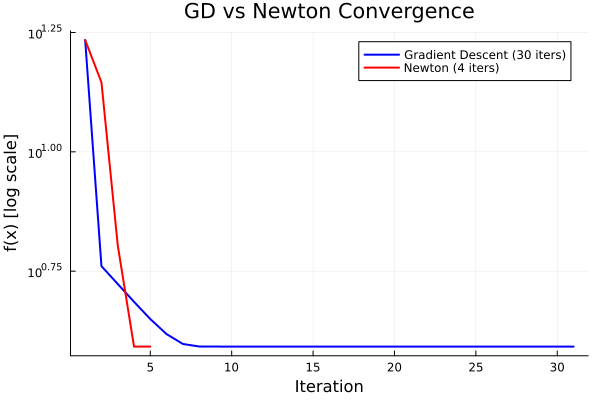

In [20]:
function newton_bt(f, ∇f, x0, α, β, eps; maxiter=1000)
    x = copy(x0)
    f_history = [f(x)]
    iter = 0
    for i in 1:maxiter
        g = ∇f(x)
        H = hessian_fd(∇f, x)
        Δx_nt = -H \ g
        λ² = g' * (H \ g)          # Newton decrement squared
        λ²/2 <= eps && break
        t = backtracking_newton(x, Δx_nt, f, ∇f, α, β)
        x = x + t*Δx_nt
        push!(f_history, f(x))
        iter = i
    end
    return x, iter, f_history
end

x_nt_bt, iters_nt, f_hist_nt = newton_bt(f_bt, ∇f_bt, x_start_nt, α_nt, β_nt, eps_nt)

println("=== Newton's Method with Backtracking ===")
println("Minimizer: ", x_nt_bt)
println("f(x*) = ", f_bt(x_nt_bt))
println("‖∇f(x*)‖ = ", norm(∇f_bt(x_nt_bt)))
println("Iterations: ", iters_nt)

p1 = plot(f_hist_gd, yscale=:log10, label="Gradient Descent ($(iters_gd) iters)", color=:blue, linewidth=2)
plot!(p1, f_hist_nt, yscale=:log10, label="Newton ($(iters_nt) iters)", color=:red, linewidth=2)
xlabel!("Iteration"); ylabel!("f(x) [log scale]"); title!("GD vs Newton Convergence")
display(p1)

## Optimisation using Quasi-Newton Method:
### The Broyden-Fletcher-Goldfarb-Shanno (BFGS) update
  

Given function:
\begin{align*}
    f(x_1, x_2, x_3) = x_{3} \log \Big( e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}} \Big) + (x_{3}-2)^2 + e^{\frac{1}{x_{1} + x_{2}}}
\end{align*}

$ \textbf{dom} \; f: \{ \mathbf{x} \in \mathbb{R}^3 : x_1 +x _2 >0, x_3 > 0 \}  $

Defining the first derivative: 

$\nabla f = [ \partial f/\partial x_1 \; \partial f/\partial x_2 \; \partial f/\partial x_3]^T   $

$$ \implies \nabla f = \begin{Bmatrix}
\frac{e^{\frac{x_{1}} {x_{3}}}}{e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}} - \frac{e^{ \frac{1}{x_1 + x_2}}}{(x_1 +x_2)^2}  \\ \\
\frac{e^{\frac{x_{2}} {x_{3}}}}{e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}} - \frac{e^{ \frac{1}{x_1 + x_2}}}{(x_1 +x_2)^2} \\ \\
 log(e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}) - \frac{x_1 e^{\frac{x_{1}} {x_{3}}} + x_2 e^{\frac{x_{2}} {x_{3}}}}{x_3 ( e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}) } + 2(x_3-2)
\end{Bmatrix}$$

Defining the Second Derivative:

The gradient vector, denoted as $\nabla f$, is the vector of partial derivatives:
$
\nabla f(x) = \left(\frac{\partial f}{\partial x_1}, \frac{\partial f}{\partial x_2}, \ldots, \frac{\partial f}{\partial x_n}\right)
$

The finite difference approximation for the gradient at a point $x$ is given by:
$
\nabla_f(x) \approx \frac{f(x + h\mathbf{i}) - f(x)}{h}
$
where $\mathbf{i}$ is a unit vector along one of the coordinate axes.

The second derivative matrix is then approximated as:
$
\nabla^2 f(x) \approx \frac{1}{h} \left(\nabla_f(x + h\mathbf{i}) - \nabla_f(x)\right)
$

The reshaped second derivative matrix is a $3 \times 3$ matrix obtained from the flattened vector.

In [21]:
# Reuse hessian_fd and ∇f_bt from Newton section
println("Hessian (finite diff) and gradient already defined above.")
println("Verifying gradient at start point: ", ∇f_bt([3.0,4.0,5.0]))

Hessian (finite diff) and gradient already defined above.
Verifying gradient at start point: [0.42662385993456065, 0.5262918545595165, 6.688172069919096]


Defining parameters for backtracking search and the start point: $\alpha = 0,4; \beta = 0,5;$ tolerance (eps) $= 10^{-5}$; Start Point: [3.0, 4.0, 5.0]

In [22]:
α_bfgs = 0.4; β_bfgs = 0.5; eps_bfgs = 1e-5
x_start_bfgs = [3.0, 4.0, 5.0]
println("BFGS params: α=$α_bfgs, β=$β_bfgs, ε=$eps_bfgs, x₀=$x_start_bfgs")

BFGS params: α=0.4, β=0.5, ε=1.0e-5, x₀=[3.0, 4.0, 5.0]


Ensuring domain:

$ \text{While} \; x + t\Delta x \notin \textbf{dom} f, \text{ set } t := \beta t $ 

Here, the direction $\Delta x$ has been taken as a parameter in the defined function and thus we need not explicitly calculate it again.

In [23]:
function ensure_domain_bfgs(x, Δx, β)
    t = 1.0
    while !in_domain(x + t*Δx)
        t *= β
    end
    return t
end
println("Domain check for BFGS direction defined.")

Domain check for BFGS direction defined.


Backtracking algorithm:

$
\text{Given a descent direction } \Delta x  \text{ for } f \text{ at } x \in \textbf{dom} f, \alpha \in (0, 0.5), \beta \in (0, 1).$

\begin{array}{l}
\text{Set } t := 1. \\ 
\text{Ensure domain:} \; \text{While} \; x + t\Delta x \notin \textbf{dom} f, \text{ set } t := \beta t \\
\text{While } f(x + t\Delta x) > f(x) + \alpha t \nabla f(x)^T \Delta x, \text{ set } t := \beta t.
\end{array}


In [24]:
function backtracking_bfgs(x, Δx, f, ∇f, α, β)
    t = 1.0
    while !in_domain(x + t*Δx)
        t *= β
    end
    while f(x + t*Δx) > f(x) + α*t*(∇f(x)' * Δx)
        t *= β
        if t < 1e-15; break; end
    end
    return t
end
println("BFGS backtracking line search defined.")

BFGS backtracking line search defined.


### Running the BFGS Algorithm: 

**Given:**
- Starting point $x_0$
- Convergence tolerance $\epsilon > 0$ $(=10^{-5})$
- Starting matrix $H_0$ (taken as Identity matrix)
  
**Initialization:** $k \gets 0$

**While:** $\| \nabla f_k \| > \epsilon$
1. Compute search direction by solving:
   $ p_k = - H_k \nabla f_k $
2. Set $x_{k+1} = x_k + \alpha_k p_k$, where $\alpha_k$ is computed from backtracking line search procedure.
3. Define $s_k = x_{k+1} - x_k$ and $y_k = \nabla f_{k+1} - \nabla f_k$.
4. Compute $H_{k+1}$ using BFGS.
5. $k \gets k + 1$

Finally, as mentioned in the implementation note to set $\rho_k $ as a constant after $y^T_k s_k$ gets smaller some certain $\epsilon$ say $10^{-5}$.\
We have used an $\epsilon = 10^{-4}$ and set the value for  $\rho_k = 10^{4}$.


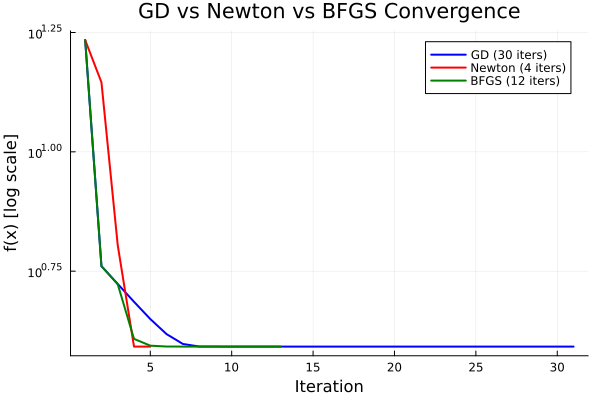

=== BFGS (Quasi-Newton) ===
Minimizer: [0.926207304123096, 0.926208139879769, 1.6534291727960921]
f(x*) = 3.908113786270299
‖∇f(x*)‖ = 5.710794308280215e-6
Iterations: 12


In [25]:
function bfgs(f, ∇f, x0, α, β, eps; maxiter=1000)
    n = length(x0)
    x = copy(x0)
    H = Matrix{Float64}(I, n, n)   # H₀ = Identity (approximation of inverse Hessian)
    g = ∇f(x)
    f_history = [f(x)]
    iter = 0
    
    for k in 1:maxiter
        norm(g) <= eps && break
        
        # Search direction
        p = -H * g
        
        # Backtracking line search
        t = backtracking_bfgs(x, p, f, ∇f, α, β)
        
        # Update
        x_new = x + t*p
        g_new = ∇f(x_new)
        
        s = x_new - x
        y = g_new - g
        
        sy = y' * s
        # Safeguard: if curvature condition fails, reset H
        if sy < 1e-4
            ρ = 1e4
        else
            ρ = 1/sy
        end
        
        # BFGS update: H_{k+1} = (I-ρsyᵀ)H(I-ρysᵀ) + ρssᵀ
        Iy = I - ρ * (s * y')
        H = Iy * H * Iy' + ρ * (s * s')
        
        x = x_new
        g = g_new
        push!(f_history, f(x))
        iter = k
    end
    return x, iter, f_history
end

x_bfgs, iters_bfgs, f_hist_bfgs = bfgs(f_bt, ∇f_bt, x_start_bfgs, α_bfgs, β_bfgs, eps_bfgs)

println("=== BFGS (Quasi-Newton) ===")
println("Minimizer: ", x_bfgs)
println("f(x*) = ", f_bt(x_bfgs))
println("‖∇f(x*)‖ = ", norm(∇f_bt(x_bfgs)))
println("Iterations: ", iters_bfgs)

# Comparison plot
p_cmp = plot(f_hist_gd,   yscale=:log10, label="GD ($(iters_gd) iters)",   color=:blue,  lw=2)
plot!(p_cmp, f_hist_nt,   yscale=:log10, label="Newton ($(iters_nt) iters)", color=:red,   lw=2)
plot!(p_cmp, f_hist_bfgs, yscale=:log10, label="BFGS ($(iters_bfgs) iters)", color=:green, lw=2)
xlabel!("Iteration"); ylabel!("f(x) [log scale]"); title!("GD vs Newton vs BFGS Convergence")
display(p_cmp)